In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

training_dirs = [
    "training",
    "training/notebooks",
    "training/scripts",
    "training/checkpoints",
    "training/saved_models",
    "training/logs",
    "training/plots",
]

for folder in training_dirs:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

print("✅ Training folder structure created successfully!")

print("\nProject Root:", PROJECT_ROOT)

✅ Training folder structure created successfully!

Project Root: C:\Users\disha\Predictive_Multimodal_Student_Engagement\student_engagement_system


In [2]:
import tensorflow as tf
import keras
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
print("OpenCV     :", cv2.__version__)
print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)
print("Scikit     :", sklearn.__version__)
print("Seaborn    :", sns.__version__)

TensorFlow : 2.21.0
Keras      : 3.15.0
OpenCV     : 5.0.0
NumPy      : 2.3.5
Pandas     : 2.3.3
Scikit     : 1.7.2
Seaborn    : 0.13.2


In [3]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd()

FER_PATH = PROJECT_ROOT / "datasets" / "raw" / "fer2013" / "fer2013.csv"

df = pd.read_csv(FER_PATH)

print("Dataset Shape:", df.shape)
print()

print(df.head())

print()

print(df["emotion"].value_counts().sort_index())

Dataset Shape: (35887, 3)

   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training

emotion
0    4953
1     547
2    5121
3    8989
4    6077
5    4002
6    6198
Name: count, dtype: int64


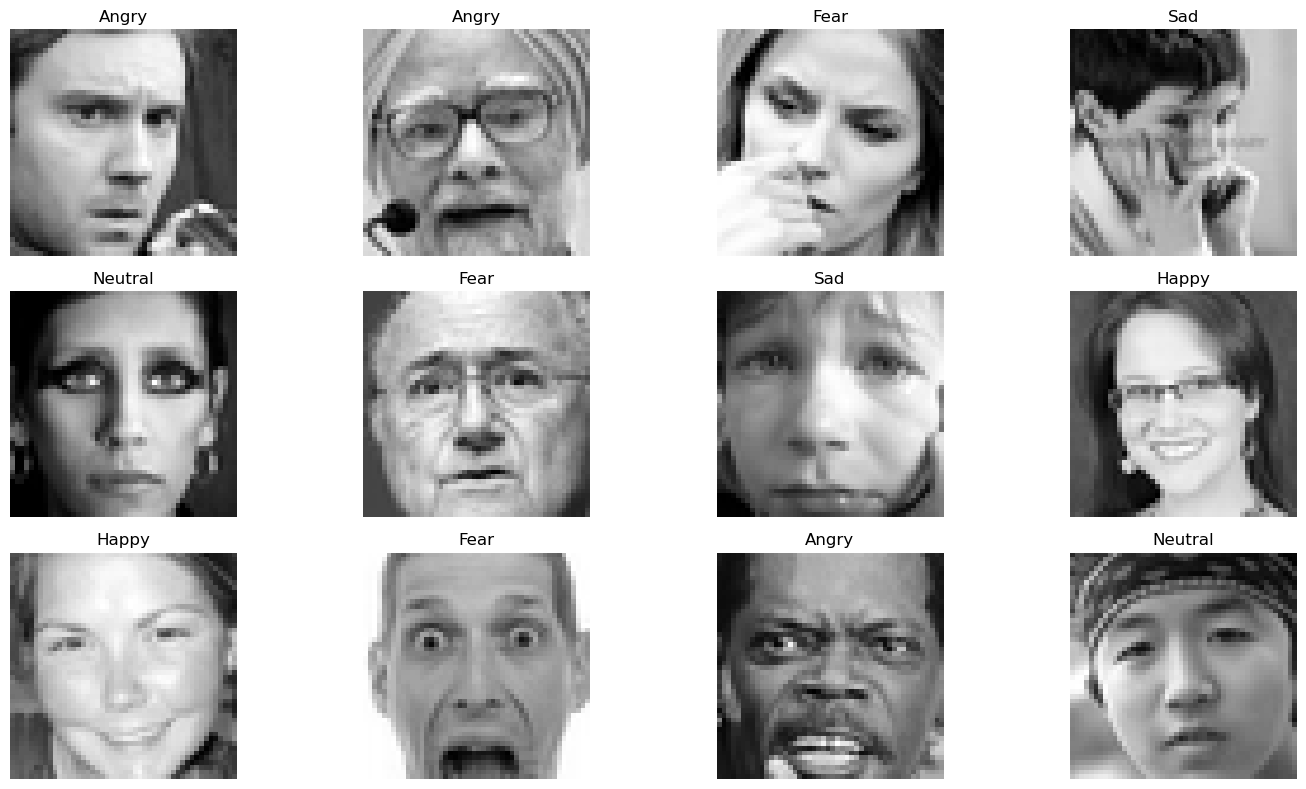

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Emotion label mapping
emotion_labels = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

plt.figure(figsize=(15, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    pixels = np.array(df.iloc[i]["pixels"].split(), dtype="float32")
    image = pixels.reshape(48, 48)

    plt.imshow(image, cmap="gray")
    plt.title(emotion_labels[df.iloc[i]["emotion"]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
import numpy as np
from tensorflow.keras.utils import to_categorical

# Convert pixel strings into NumPy arrays
X = np.array([
    np.fromstring(pixels, dtype=np.uint8, sep=' ')
    for pixels in df['pixels']
])

# Reshape to image format
X = X.reshape(-1, 48, 48)

# Labels
y = df['emotion'].values

print("Image Shape :", X.shape)
print("Labels Shape:", y.shape)

# Normalize
X = X.astype("float32") / 255.0

# One-hot encode labels
y = to_categorical(y, num_classes=7)

print("One-hot labels:", y.shape)

Image Shape : (35887, 48, 48)
Labels Shape: (35887,)
One-hot labels: (35887, 7)


In [6]:
from sklearn.model_selection import train_test_split

# Split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split temp into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training :", X_train.shape)
print("Validation:", X_val.shape)
print("Testing :", X_test.shape)

Training : (25120, 48, 48)
Validation: (5383, 48, 48)
Testing : (5384, 48, 48)


In [7]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess(image, label):
    # Add channel dimension (48,48) -> (48,48,1)
    image = tf.expand_dims(image, axis=-1)

    # Convert grayscale to RGB
    image = tf.image.grayscale_to_rgb(image)

    # Resize
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    return image, label


train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = train_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("TensorFlow datasets created successfully!")

TensorFlow datasets created successfully!


In [8]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32, 7)


In [9]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load pretrained EfficientNetB0
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
base_model.trainable = False

# Build classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.3)(x)

outputs = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 4,379,306 (16.71 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [10]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

# Apply augmentation only to training data
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

print("✅ Data augmentation added successfully!")

✅ Data augmentation added successfully!


In [11]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

checkpoint = ModelCheckpoint(
    "training/saved_models/emotion_model_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]

print("✅ Callbacks Ready")

✅ Callbacks Ready


In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5


C:\Users\disha\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


785/785 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2328 - loss: 1.8369
Epoch 1: val_accuracy improved from None to 0.25042, saving model to training/saved_models/emotion_model_best.keras

Epoch 1: finished saving model to training/saved_models/emotion_model_best.keras
785/785 ━━━━━━━━━━━━━━━━━━━━ 1305s 2s/step - accuracy: 0.2328 - loss: 1.8369 - val_accuracy: 0.2504 - val_loss: 1.8140 - learning_rate: 1.0000e-04
Epoch 2/5
785/785 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2426 - loss: 1.8230
Epoch 2: val_accuracy did not improve from 0.25042
785/785 ━━━━━━━━━━━━━━━━━━━━ 1337s 2s/step - accuracy: 0.2426 - loss: 1.8230 - val_accuracy: 0.2504 - val_loss: 1.8161 - learning_rate: 1.0000e-04
Epoch 3/5
785/785 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2486 - loss: 1.8209
Epoch 3: val_accuracy did not improve from 0.25042
785/785 ━━━━━━━━━━━━━━━━━━━━ 1205s 2s/step - accuracy: 0.2486 - loss: 1.8209 - val_accuracy: 0.2504 - val_loss: 1.8124 - learning_rate: 1.0000e-04
Epoch 4/5
785/785

In [13]:
model.save("models/emotion_recognition/emotion_model.keras")

FileNotFoundError: [Errno 2] No such file or directory: 'models/emotion_recognition/emotion_model.keras'

In [14]:
from pathlib import Path

Path("models/emotion_recognition").mkdir(parents=True, exist_ok=True)

print("Folder Created Successfully")

Folder Created Successfully


In [15]:
model.save("models/emotion_recognition/emotion_model.keras")

print("Emotion Model Saved Successfully")

Emotion Model Saved Successfully


In [16]:
!pip install opencv-python

In [18]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load trained model
model = load_model("models/emotion_recognition/emotion_model.keras")

emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
]

face_detector = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")

cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_detector.detectMultiScale(gray, 1.3, 5)

    print("Faces detected:", len(faces))

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

    cv2.imshow("Test", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

Faces detected: 0
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces detected: 1
Faces dete

In [19]:
print(face_detector.empty())

False
